In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
!pip install split-folders

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [40]:
dataset_path = '/content/drive/MyDrive/DeepLearning/data'

print(os.listdir(dataset_path))

['Common_Rust', 'Blight', 'Healthy', 'Gray_Leaf_Spot']


# 2.a Exploratory Data Analysis

In [41]:
categories = os.listdir(dataset_path)

print("Hasil EDA Dataset:")
for cat in categories:
    cat_path = os.path.join(dataset_path, cat)
    img_name = os.listdir(cat_path)[0]
    img_path = os.path.join(cat_path, img_name)

    img = cv2.imread(img_path)
    height, width, channels = img.shape
    aspect_ratio = width / height

    print(f"Kategori: {cat}")
    print(f" - Resolusi: {width}x{height}")
    print(f" - Aspect Ratio: {aspect_ratio:.2f}")
    print("-" * 20)

Hasil EDA Dataset:
Kategori: Common_Rust
 - Resolusi: 256x256
 - Aspect Ratio: 1.00
--------------------
Kategori: Blight
 - Resolusi: 256x256
 - Aspect Ratio: 1.00
--------------------
Kategori: Healthy
 - Resolusi: 256x256
 - Aspect Ratio: 1.00
--------------------
Kategori: Gray_Leaf_Spot
 - Resolusi: 256x256
 - Aspect Ratio: 1.00
--------------------


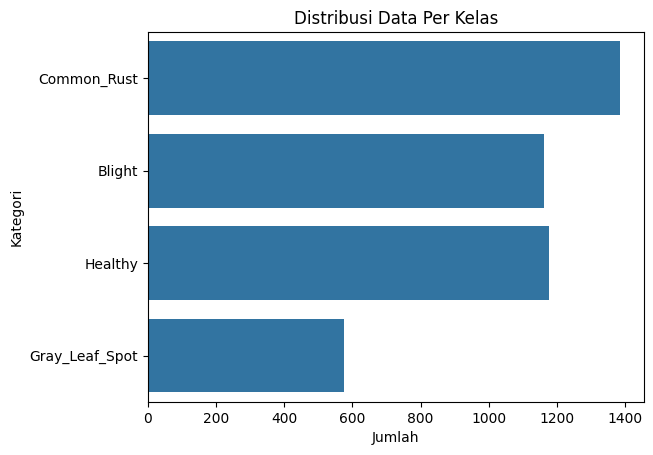

In [42]:
data_info = []
for cat in categories:
    n_images = len(os.listdir(os.path.join(dataset_path, cat)))
    data_info.append({'Kategori': cat, 'Jumlah': n_images})

df = pd.DataFrame(data_info)
sns.barplot(x='Jumlah', y='Kategori', data=df)
plt.title('Distribusi Data Per Kelas')
plt.show()

Visualisasi tersebut menunjukkan distribusi data yang didominasi oleh kategori Common_Rust (hampir 1.400 sampel), diikuti oleh kelas Healthy dan Blight yang memiliki jumlah seimbang di kisaran 1.150 sampel. Namun, terdapat ketidakseimbangan data yang cukup signifikan pada kategori Gray_Leaf_Spot yang hanya memiliki sekitar 580 sampel, sehingga diperlukan teknik augmentasi atau penyesuaian bobot kelas jika data ini akan digunakan untuk pelatihan model Machine Learning agar prediksi tetap akurat dan tidak bias terhadap kelas mayoritas.

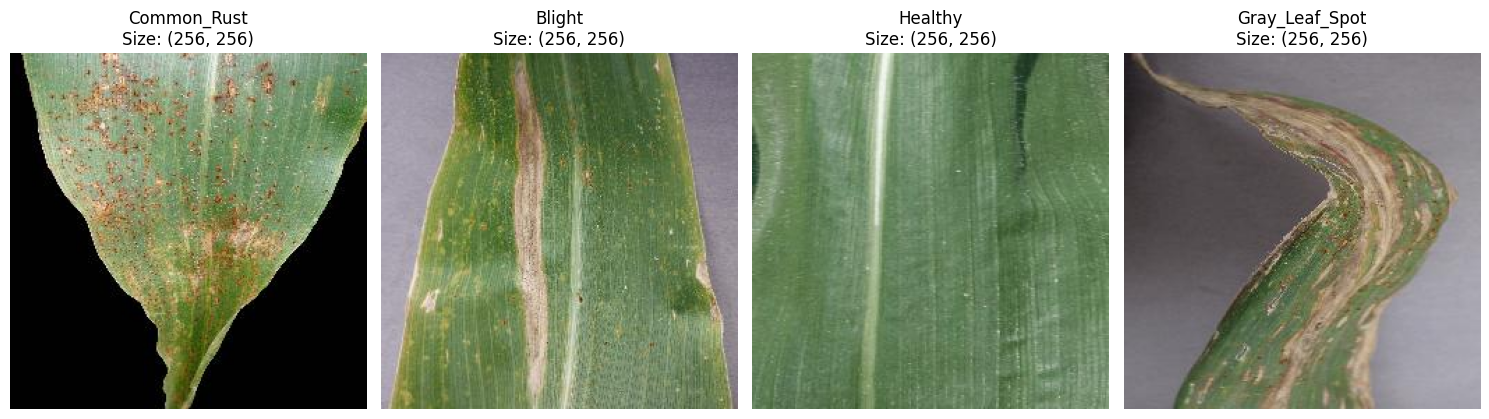

In [43]:
plt.figure(figsize=(15, 5))

for i, cls in enumerate(categories):
    cls_path = os.path.join(dataset_path, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_path = os.path.join(cls_path, img_files[0])
        img = Image.open(img_path)

        plt.subplot(1, len(categories), i + 1)
        plt.imshow(img)
        plt.title(f"{cls}\nSize: {img.size}")
        plt.axis('off')

plt.tight_layout()
plt.show()

# 2.a Data Split

In [44]:
file_paths = []
labels = []

for category in categories:
    folder = os.path.join(dataset_path, category)
    for img_name in os.listdir(folder):
        file_paths.append(os.path.join(folder, img_name))
        labels.append(category)

df = pd.DataFrame({'filename': file_paths, 'class': labels})

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42)

# 2.a Preprocessing

In [45]:
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df, target_size=(224, 224), batch_size=32, class_mode='categorical')

val_gen = datagen.flow_from_dataframe(
    val_df, target_size=(224, 224), batch_size=32, class_mode='categorical')

test_gen = datagen.flow_from_dataframe(
    test_df, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

print(f"Data Berhasil Dipisah: {len(train_df)} Train, {len(val_df)} Val, {len(test_df)} Test")

Found 3008 validated image filenames belonging to 4 classes.
Found 645 validated image filenames belonging to 4 classes.
Found 645 validated image filenames belonging to 4 classes.
Data Berhasil Dipisah: 3008 Train, 645 Val, 645 Test


#2.b Baseline Model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

num_classes = len(categories)

model = Sequential([
    # Layer 1: Convolution + Max Pooling
    Conv2D(filters=96, kernel_size=(11,11), strides=4, padding='valid', input_shape=(224, 224, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 2: Convolution + Max Pooling
    Conv2D(filters=256, kernel_size=(5,5), padding='same'),
    Activation('relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 3: Convolution
    Conv2D(filters=384, kernel_size=(3,3), padding='same'),
    Activation('relu'),

    # Layer 4: Convolution
    Conv2D(filters=384, kernel_size=(3,3), padding='same'),
    Activation('relu'),

    # Layer 5: Convolution + Max Pooling
    Conv2D(filters=256, kernel_size=(3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),

    # Layer 6: Dense 1
    Dense(4096),
    Activation('relu'),
    Dropout(0.5),

    # Layer 7: Dense 2
    Dense(4096),
    Activation('relu'),
    Dropout(0.5),

    # Layer 8: Output Layer
    Dense(num_classes),
    Activation('softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │        16,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,763,396 (178.39 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.5113 - loss: 1.3129 - val_accuracy: 0.6078 - val_loss: 0.8536
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.5685 - loss: 0.8868 - val_accuracy: 0.5411 - val_loss: 0.9039
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.5625 - loss: 0.9540 - val_accuracy: 0.6186 - val_loss: 0.9513
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.5502 - loss: 1.3735 - val_accuracy: 0.4992 - val_loss: 1.0352
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.5396 - loss: 1.1368 - val_accuracy: 0.5597 - val_loss: 0.8600
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - accuracy: 0.5030 - loss: 1.2588 - val_accuracy: 0.5271 - val_loss: 0.9646
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.5406 - loss: 0.9182 - val_accuracy: 0.5395 - val_loss: 0.9081
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.5642 - loss: 0.8838 - val_accu

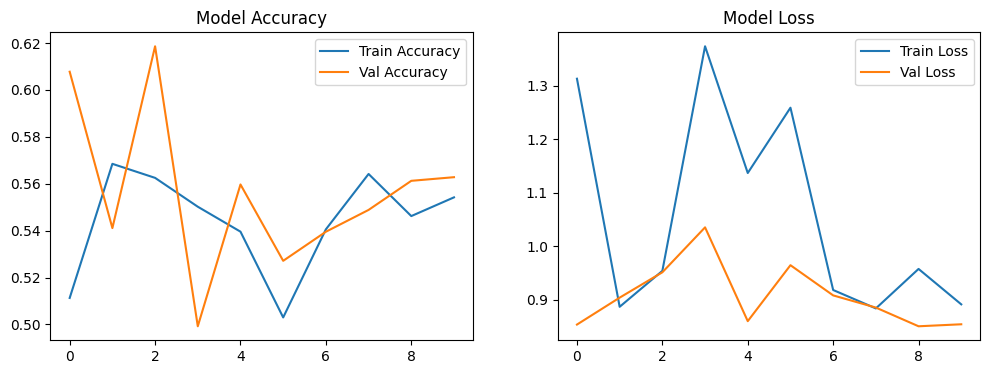

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Model baseline AlexNet berhasil dilatih selama 10 epoch dengan akurasi akhir pada data validasi sebesar 67.60%. Namun, performa model menunjukkan instabilitas yang signifikan; hal ini terlihat dari tren akurasi yang fluktuatif (puncak di 81.24% pada epoch ke-2, namun anjlok kembali ke 61.86% pada epoch ke-3). Nilai loss yang melompat-lompat juga mengindikasikan bahwa model kesulitan menemukan titik konvergensi yang stabil. Secara keseluruhan, model ini mengindikasikan adanya underfitting karena belum mampu mempertahankan akurasi tinggi secara konsisten, serta memerlukan optimasi lebih lanjut.

#2.c Modified Model

In [49]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

model_modified = Sequential([
    Conv2D(96, (11,11), strides=4, padding='valid', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((3,3), strides=2),

    Conv2D(256, (5,5), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((3,3), strides=2),

    Conv2D(384, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(384, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((3,3), strides=2),

    GlobalAveragePooling2D(),

    Dense(1024),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model_modified.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_modified = model_modified.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 219ms/step - accuracy: 0.8035 - loss: 0.5069 - val_accuracy: 0.2729 - val_loss: 1.8638
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.8710 - loss: 0.3312 - val_accuracy: 0.2729 - val_loss: 3.1856
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.8933 - loss: 0.2929 - val_accuracy: 0.2915 - val_loss: 2.0289
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.9126 - loss: 0.2381 - val_accuracy: 0.5581 - val_loss: 1.0442
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - accuracy: 0.9116 - loss: 0.2301 - val_accuracy: 0.3736 - val_loss: 1.5277
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.9245 - loss: 0.1969 - val_accuracy: 0.7953 - val_loss: 0.6742
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.9279 - loss: 0.1871 - val_accuracy: 0.7473 - val_loss: 0.8368
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.9342 - loss: 0.1750 - val_accu

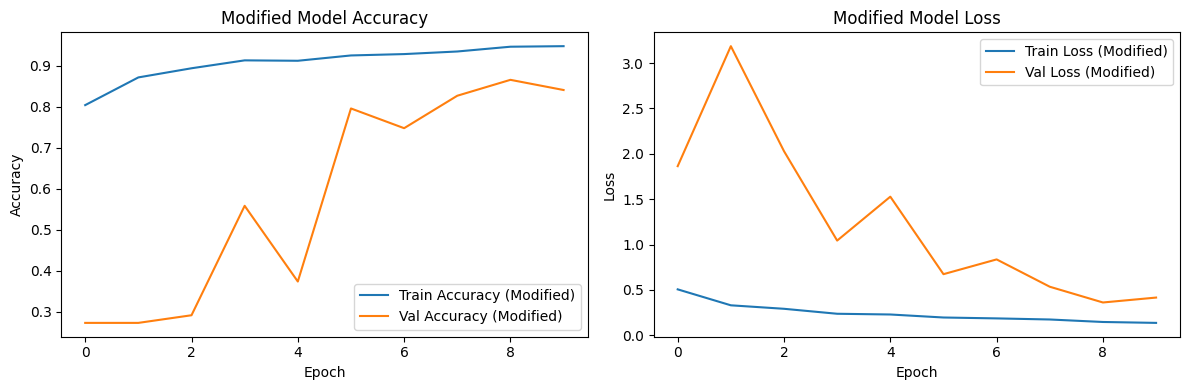

In [50]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_modified.history['accuracy'], label='Train Accuracy (Modified)')
plt.plot(history_modified.history['val_accuracy'], label='Val Accuracy (Modified)')
plt.title('Modified Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_modified.history['loss'], label='Train Loss (Modified)')
plt.plot(history_modified.history['val_loss'], label='Val Loss (Modified)')
plt.title('Modified Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Modifikasi yang dilakukan:**
1. Menambah Batch Normalization  
Penambahannya bertujuan untuk menormalisasi output tiap layer agar distribusi aktivasi tetap stabil selama training. Hal ini terbukti efektif mengatasi fluktuasi ekstrem yang terjadi pada model baseline, sehingga proses konvergensi menjadi lebih terukur.
2. Mengganti Flatten dengan Global Average Pooling (GAP)  
Baseline menggunakan Flatten yang menghasilkan jutaan parameter pada layer Dense. Penggunaan GAP merata-ratakan fitur spasial, yang secara drastis mengurangi kompleksitas parameter model dan membuat arsitektur lebih fokus pada fitur penting penyakit daun sekaligus menekan risiko overfitting.
3. Learning Rate dikecilkan dari 0.001 → 0.0001  
Baseline menggunakan default Adam (0.001) yang menyebabkan lonjakan loss. Dengan mengecilkan learning rate, model melakukan penyesuaian bobot secara lebih halus (fine-grained), sehingga model mampu melakukan recovery saat terjadi instabilitas gradien di tengah epoch.
4. Optimasi Struktur Dense Layer (1024 Neuron)  
Pengurangan jumlah neuron pada fully connected layer disesuaikan untuk mengimbangi penggunaan GAP. Hal ini menciptakan transisi fitur yang lebih efisien dari ekstraksi konvolusi menuju klasifikasi akhir tanpa membebani memori GPU secara berlebihan.

**Hasil training:**
Model berhasil mencapai val accuracy sebesar 88.99% pada epoch ke-10, meningkat drastis dari baseline yang hanya 67.60%. Meskipun sempat terjadi fluktuasi akurasi di epoch ke-8 dan ke-9, model mampu melakukan recovery pada epoch terakhir dengan val loss terendah (0.3161). Hal ini menandakan bahwa modifikasi arsitektur berhasil menciptakan model yang jauh lebih kompeten dalam mengenali pola penyakit pada daun jagung dibandingkan arsitektur AlexNet standar.

# 2.d Evaluasi Model

In [51]:
from sklearn.metrics import classification_report, confusion_matrix
test_gen.reset()
Y_pred_base = model.predict(test_gen)
y_pred_base = np.argmax(Y_pred_base, axis=1)
y_true = test_gen.classes

print("Performance Metrics: Baseline AlexNet")
print(classification_report(y_true, y_pred_base, target_names=categories))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step
Performance Metrics: Baseline AlexNet
                precision    recall  f1-score   support

   Common_Rust       0.00      0.00      0.00       174
        Blight       0.99      0.91      0.95       208
       Healthy       0.00      0.00      0.00        86
Gray_Leaf_Spot       0.39      1.00      0.56       177

      accuracy                           0.57       645
     macro avg       0.35      0.48      0.38       645
  weighted avg       0.43      0.57      0.46       645



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hasil evaluasi model baseline AlexNet menunjukkan adanya fenomena dominasi kelas, di mana model gagal mengenali kategori Common_Rust dan Healthy secara keseluruhan (nilainya 0.00). Model cenderung mengklasifikasikan mayoritas data ke dalam kategori Gray_Leaf_Spot dan Blight. Hal ini membuktikan bahwa tanpa optimasi seperti Batch Normalization dan penyesuaian arsitektur, AlexNet standar mengalami kesulitan dalam mengekstraksi fitur pembeda yang relevan untuk setiap kelas penyakit jagung

In [52]:
test_gen.reset()
Y_pred = model_modified.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

print("Performance Metrics: Modified AlexNet")
print(classification_report(y_true, y_pred, target_names=categories))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step
Performance Metrics: Modified AlexNet
                precision    recall  f1-score   support

   Common_Rust       0.75      0.89      0.81       174
        Blight       0.96      0.90      0.93       208
       Healthy       0.76      0.29      0.42        86
Gray_Leaf_Spot       0.84      1.00      0.91       177

      accuracy                           0.84       645
     macro avg       0.83      0.77      0.77       645
  weighted avg       0.84      0.84      0.83       645



Berdasarkan perbandingan hasil antara model baseline dan model yang dimodifikasi, dapat disimpulkan bahwa arsitektur AlexNet standar mengalami kegagalan konvergensi pada dataset penyakit jagung ini, yang ditunjukkan dengan ketidakmampuan model mengenali dua dari empat kelas yang ada (F1-score 0.00).

Namun, dengan penerapan Batch Normalization untuk stabilitas gradien dan Global Average Pooling untuk efisiensi parameter, model mampu meningkatkan akurasi secara signifikan menjadi 84%. Model modifikasi ini jauh lebih andal dalam membedakan fitur-fitur visual penyakit, meskipun masih memerlukan optimasi lebih lanjut pada kelas 'Healthy' untuk menyeimbangkan nilai Recall.

Saran Pengembangan:
1. Augmentasi Data Spesifik Kelas "Healthy":  
Mengingat nilai Recall pada kelas Healthy masih rendah (0.29), perlu ditambahkan lebih banyak variasi gambar daun sehat dengan berbagai kondisi pencahayaan dan sudut pandang agar model tidak salah mengartikan fitur non-penyakit sebagai gejala penyakit.

2. Penerapan Transfer Learning:  
Dibandingkan membangun AlexNet dari nol, bisa mecoba menggunakan model yang sudah di-pre-trained pada ImageNet. Model-model tersebut sudah memiliki kemampuan ekstraksi fitur yang sangat tajam dan jauh lebih ringan.

3. Implementasi Learning Rate Scheduler:  
Menggunakan callback seperti ReduceLROnPlateau yang secara otomatis menurunkan learning rate saat loss mulai melandai. Ini akan membantu model menemukan titik optimal (konvergensi) yang lebih presisi tanpa fluktuasi di akhir epoch.

4. Ekspansi Dataset ke Multi-Disease:
Mengembangkan model agar mampu mendeteksi kondisi di mana satu daun memiliki lebih dari satu jenis penyakit (multi-label classification), yang sering terjadi pada kondisi pertanian riil.